# Evaluation and Inference

This notebook compares all trained models on held-out test data, then demonstrates
real-world inference on a public domain book excerpt — both the original text and
a simplified version — to show how the model can detect changes in reading difficulty.

## Model Performance Comparison

In [6]:
import pandas as pd
import textstat
import joblib
import numpy as np
import matplotlib.pyplot as plt

In [7]:
columns = ['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'Best Params']
results = pd.read_csv('all_model_results.csv', names=columns, index_col=False)
results.head(8)

/var/folders/3p/rr2nrbcj6j79v6mwqtwtdzbw0000gn/T/ipykernel_68457/3391785893.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  results = pd.read_csv('all_model_results.csv', names=columns, index_col=False)


,Model,MAE,MSE,RMSE,R2,Best Params
0,Model,MAE,MSE,RMSE,R2,Params
1,Linear Regression,0.25058390669662917,0.08627987771568245,0.29373436590852364,0.9959687201266115,Default
2,Ridge Regression,0.25075666937417423,0.08628880683175018,0.29374956481967796,0.995968302928919,{'alpha': np.float64(0.11)}
3,Lasso Regression,0.2538575812166381,0.09005396682910853,0.30008993123580224,0.99579238226098,{'alpha': np.float64(0.01)}
4,Decision Tree,0.39662366618888356,0.4329717728786053,0.6580059064162003,0.9797701336631173,"{'max_depth': 15, 'min_samples_leaf': 4, 'min_..."
5,Random Forest,0.3344147157190635,0.19297040133779259,0.4392839643531193,0.9909837876957104,"{'max_depth': 20, 'max_features': 'sqrt', 'min..."
6,XGBRegressor,0.32162097096443176,0.1739925891160965,0.4171241890805381,0.9918705224990845,"{'objective': 'reg:squarederror', 'base_score'..."
7,Stacking Regressor,0.25101769915087446,0.08646396423529222,0.29404755437733576,0.9959601189985025,"{'cv': 5, 'estimators': [('lr', LinearRegressi..."


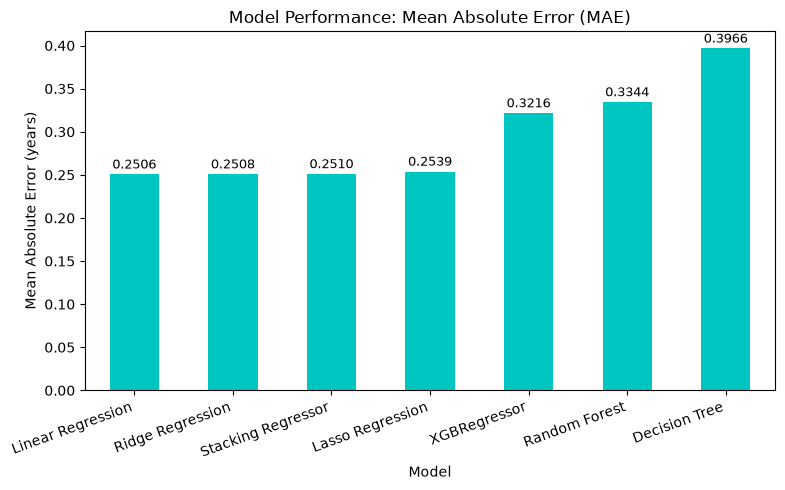

In [8]:
results_sorted = results.sort_values(by='MAE')

results_sorted = results.copy()
results_sorted['MAE'] = pd.to_numeric(results_sorted['MAE'], errors='coerce')
results_sorted = results_sorted.dropna(subset=['MAE']).sort_values('MAE')

ax = results_sorted.plot(
    x='Model',
    y='MAE',
    kind='bar',
    color='#00c6c2',
    legend=False,
    figsize=(8, 5)
)
plt.title('Model Performance: Mean Absolute Error (MAE)')
plt.ylabel('Mean Absolute Error (years)')
plt.xlabel('Model')
plt.xticks(rotation=20, ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()

/var/folders/3p/rr2nrbcj6j79v6mwqtwtdzbw0000gn/T/ipykernel_68457/969068095.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')


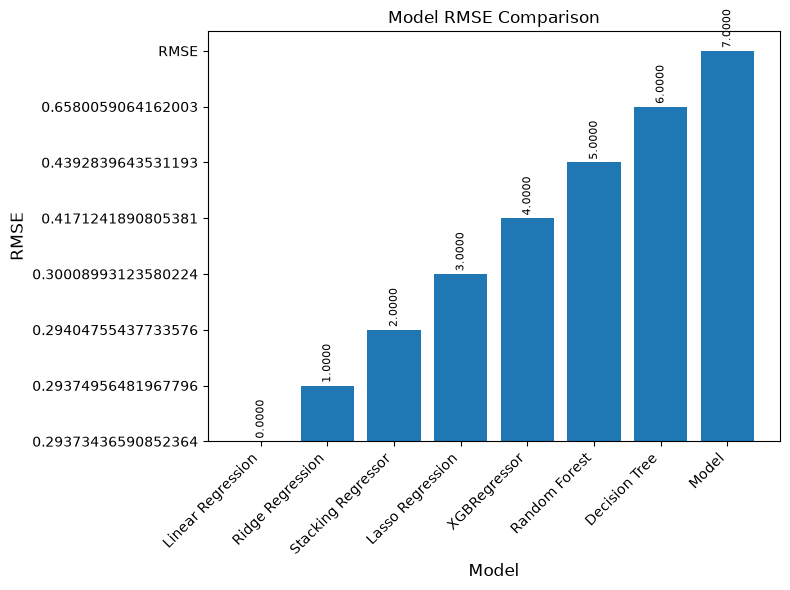

In [9]:
results_sorted = results.sort_values(by='RMSE')
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(results_sorted['Model'], results_sorted['RMSE'])
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
ax.set_title('Model RMSE Comparison')
ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2, rotation=90)
plt.tight_layout()
plt.show()

## Feature Extraction

In [10]:
def extract_features(text):
    words = text.split()
    word_count = max(len(words), 1)
    complex_count = sum(1 for w in words if textstat.syllable_count(w) >= 3)
    difficult_count = textstat.difficult_words(text)
    return {
        'word_count': word_count,
        'average_word_length': sum(len(w) for w in words) / word_count,
        'complex_word_count': complex_count,
        'percent_complex_words': complex_count / word_count,
        'difficult_word_count': difficult_count,
        'percent_difficult_words': difficult_count / word_count,
        'sentence_count': textstat.sentence_count(text),
        'syllables_per_word': textstat.syllable_count(text) / word_count,
        'polysyllable_count': complex_count,
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'automated_readability_index': textstat.automated_readability_index(text),
        'dale_chall_readability_score': textstat.dale_chall_readability_score(text),
        'difficult_words': difficult_count,
        'linsear_write_formula': textstat.linsear_write_formula(text),
        'spache_readability': textstat.spache_readability(text),
        'reading_time': textstat.reading_time(text),
    }

feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words',
    'sentence_count', 'syllables_per_word', 'polysyllable_count', 'flesch_reading_ease',
    'automated_readability_index', 'dale_chall_readability_score', 'difficult_words',
    'linsear_write_formula', 'spache_readability', 'reading_time'
]

## Example: Evaluating a New Text

**Source:** Jane Eyre by Charlotte Bronte (1847) — public domain

We test the model on a passage known to have a high reading age (~15),
then on a simplified version of the same passage aimed at age 10,
to demonstrate that the model correctly detects the change in complexity.

In [11]:
# Original Jane Eyre passage — high reading age
test_text = """There was no possibility of taking a walk that day. We had been wandering, 
indeed, in the leafless shrubbery an hour in the morning; but since dinner, the cold winter wind 
had brought with it clouds so sombre, and a rain so penetrating, that further outdoor exercise was 
now out of the question. I was glad of it, for I never liked long walks, especially on chilly afternoons. 
Dreadful to me was the coming home in the raw twilight, with nipped fingers and toes, and a heart 
saddened by the chidings of Bessie, the nurse, and humbled by the consciousness of my physical 
inferiority to Eliza, John, and Georgiana Reed. The said Eliza, John, and Georgiana were now 
clustered round their mama in the drawing-room, where she lay reclined on a sofa by the fireside, 
and with her darlings about her, looked perfectly happy. They were not permitted to associate with me 
for Mrs. Reed was a woman of rigid principle and high tone, who had regulated her household with 
precision, and who never allowed herself or her children to be contaminated by low associations."""

In [12]:
# Simplified version of the same passage — aimed at age 10
simplified_test_text = """It was too cold and wet to go for a walk that day. We had walked in the 
garden that morning, but after dinner the wind turned cold and it started to rain hard, so we had 
to stay inside. I did not mind at all, because I never liked long walks in cold weather. Coming home 
in the dark with cold fingers and toes was not fun, especially when Bessie the nurse told me off and 
I felt left out next to Eliza, John, and Georgiana Reed. The three of them were now sitting with 
their mother in the sitting room. She was resting on the sofa by the fire, surrounded by her children, 
and she looked very happy. I was not allowed to sit with them. Mrs. Reed believed that children 
should only spend time with people of their own kind, and she thought I was not good enough for 
her family."""

## Predict on Original Text

In [13]:
test_df = pd.DataFrame([extract_features(test_text)], columns=feature_columns)
target_age = 15

model_names = [
    ('Decision Tree', '../models/decision_tree_regressor.joblib'),
    ('Random Forest', '../models/random_forest_regressor.joblib'),
    ('Lasso Regression', '../models/lasso_regression.joblib'),
    ('Ridge Regression', '../models/ridge_regression.joblib'),
    ('Linear Regression', '../models/linear_regression.joblib'),
    ('Stacking Regressor', '../models/stacking_regressor.joblib'),
    ('XGBoost', '../models/xgb_model.joblib'),
]

original_predictions = {}
for name, path in model_names:
    model = joblib.load(path)
    pred = model.predict(test_df)[0]
    original_predictions[name] = pred
    suitable = 'suitable' if pred <= target_age else 'NOT suitable'
    print(f'{name:<22} predicted age: {pred:.2f}  -> {suitable} for age {target_age}')

fk_age = textstat.flesch_kincaid_grade(test_text) + 5
print(f'\nFlesch-Kincaid UK reading age: {fk_age:.2f}')

Decision Tree          predicted age: 17.00  -> NOT suitable for age 15
Random Forest          predicted age: 16.93  -> NOT suitable for age 15
Lasso Regression       predicted age: 17.53  -> NOT suitable for age 15
Ridge Regression       predicted age: 17.76  -> NOT suitable for age 15
Linear Regression      predicted age: 17.78  -> NOT suitable for age 15
Stacking Regressor     predicted age: 17.75  -> NOT suitable for age 15
XGBoost                predicted age: 17.37  -> NOT suitable for age 15

Flesch-Kincaid UK reading age: 17.70


## Predict on Simplified Text

In [14]:
simplified_df = pd.DataFrame([extract_features(simplified_test_text)], columns=feature_columns)
target_age = 10

simplified_predictions = {}
for name, path in model_names:
    model = joblib.load(path)
    pred = model.predict(simplified_df)[0]
    simplified_predictions[name] = pred
    suitable = 'suitable' if pred <= target_age else 'NOT suitable'
    print(f'{name:<22} predicted age: {pred:.2f}  -> {suitable} for age {target_age}')

fk_age_simplified = textstat.flesch_kincaid_grade(simplified_test_text) + 5
print(f'\nFlesch-Kincaid UK reading age: {fk_age_simplified:.2f}')

Decision Tree          predicted age: 10.75  -> NOT suitable for age 10
Random Forest          predicted age: 10.46  -> NOT suitable for age 10
Lasso Regression       predicted age: 11.54  -> NOT suitable for age 10
Ridge Regression       predicted age: 11.76  -> NOT suitable for age 10
Linear Regression      predicted age: 11.78  -> NOT suitable for age 10
Stacking Regressor     predicted age: 11.74  -> NOT suitable for age 10
XGBoost                predicted age: 11.41  -> NOT suitable for age 10

Flesch-Kincaid UK reading age: 11.71


## Compare Original vs Simplified

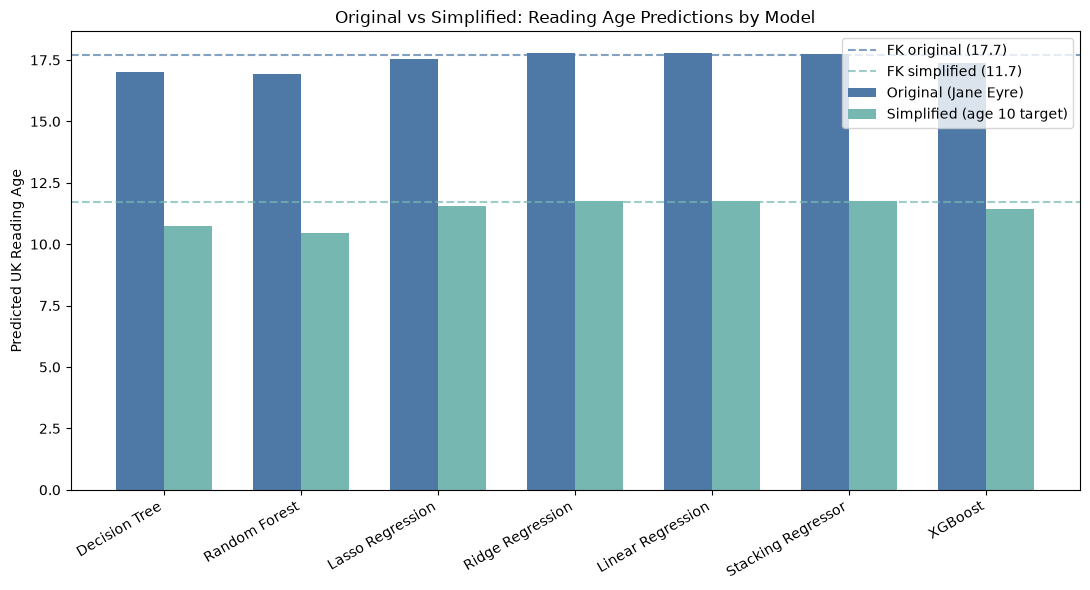

In [15]:
names = list(original_predictions.keys())
orig_ages = [original_predictions[n] for n in names]
simp_ages = [simplified_predictions[n] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, orig_ages, width, label='Original (Jane Eyre)', color='#4e79a7')
ax.bar(x + width/2, simp_ages, width, label='Simplified (age 10 target)', color='#76b7b2')

ax.axhline(y=fk_age, color='#4e79a7', linestyle='--', alpha=0.7, label=f'FK original ({fk_age:.1f})')
ax.axhline(y=fk_age_simplified, color='#76b7b2', linestyle='--', alpha=0.7, label=f'FK simplified ({fk_age_simplified:.1f})')

ax.set_ylabel('Predicted UK Reading Age')
ax.set_title('Original vs Simplified: Reading Age Predictions by Model')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()